# Exploration des données foudre — Meteorage
Analyse du fichier `segment_alerts_all_airports_train.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Import des données

In [3]:
FILE_PATH = "segment_alerts_all_airports_train.csv"

df = pd.read_csv(FILE_PATH)
print("Fichier chargé avec succès")

Fichier chargé avec succès


## 2. Aperçu général

In [4]:
print(f"Nombre de lignes    : {len(df):,}")
print(f"Nombre de colonnes  : {df.shape[1]}")
print(f"\nColonnes : {list(df.columns)}")

Nombre de lignes    : 507,071
Nombre de colonnes  : 13

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground']


In [5]:
# type des colonnes

df.dtypes

lightning_id                        int64
lightning_airport_id                int64
date                                  str
lon                               float64
lat                               float64
amplitude                         float64
maxis                             float64
icloud                               bool
dist                              float64
azimuth                           float64
airport                               str
airport_alert_id                  float64
is_last_lightning_cloud_ground     object
dtype: object

In [6]:
# conversion de "date" en type "datetime"
df['date'] = pd.to_datetime(df['date'], utc=True)

In [ ]:
# les 5 premières valeurs

df.head()

## 3. Valeurs manquantes

In [ ]:
missing = pd.DataFrame({
    'nb_manquants': df.isnull().sum(),
    'pct_manquants (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values('pct_manquants (%)', ascending=False)
print(missing.to_string())

## 4. Statistiques descriptives

In [ ]:
df.describe(include='all')

In [ ]:
# nombre d'éclairs en terme de distance

bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

result = dist_cat.value_counts().sort_index().to_frame(name='nb_eclairs')
result['pct (%)'] = (result['nb_eclairs'] / len(df) * 100).round(2)

result

In [ ]:
# Pourcentage par type d'éclair
print("=== Type d'éclair ===")
type_result = df['icloud'].value_counts().to_frame(name='nb_eclairs')
type_result.index = ['Intra-nuage (True)', 'Nuage-sol (False)']
type_result['pct (%)'] = (type_result['nb_eclairs'] / len(df) * 100).round(2)
print(type_result)

In [ ]:
# Croisement distance x type
print("\n=== Croisement distance x type ===")
bins = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']

dist_cat = pd.cut(df['dist'], bins=bins, labels=labels)

cross = pd.crosstab(dist_cat, df['icloud'], margins=True)
cross.columns = ['Nuage-sol', 'Intra-nuage', 'Total']
cross['pct_nuage_sol (%)'] = (cross['Nuage-sol'] / cross['Total'] * 100).round(2)
cross['pct_intra_nuage (%)'] = (cross['Intra-nuage'] / cross['Total'] * 100).round(2)

cross

In [ ]:
# stats sur la durée d'une alerte en minutes

# Filtrer les éclairs avec un alert_airport_id
alerts = df[df['airport_alert_id'].notna()].copy()

# Durée de chaque alerte = max(date) - min(date) par alerte
duree = alerts.groupby(['airport', 'airport_alert_id'])['date'].agg(
    debut='min',
    fin='max'
)

duree['duree_minutes'] = (duree['fin'] - duree['debut']).dt.total_seconds() / 60


print(f"Durée médiane d'une alerte : {duree['duree_minutes'].median():.2f} minutes")
print(f"Durée moyenne              : {duree['duree_minutes'].mean():.2f} minutes")
print(f"Durée min                  : {duree['duree_minutes'].min():.2f} minutes")
print(f"Durée max                  : {duree['duree_minutes'].max():.2f} minutes")

In [10]:
# Nombre d'alertes orageuses

nb_alertes = df.groupby(['airport', 'airport_alert_id']).ngroups
print(f"Nombre d'alertes orageuses : {nb_alertes}")
print(df.groupby("airport")["airport_alert_id"].nunique())

Nombre d'alertes orageuses : 2627
airport
Ajaccio     530
Bastia      532
Biarritz    590
Nantes      206
Pise        769
Name: airport_alert_id, dtype: int64


In [8]:
df_feat = pd.read_parquet("features.parquet")

# Récupérer la date du premier éclair CG de chaque alerte
first_cg = (
    df[df["icloud"] == False]
    .groupby(["airport", "airport_alert_id"])["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "t_start"})
)

df = df_feat.merge(first_cg, on=["airport", "airport_alert_id"], how="left")
df["hour"] = df["t_start"].dt.hour
df["month"] = df["t_start"].dt.month
df["season"] = df["month"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne"
})

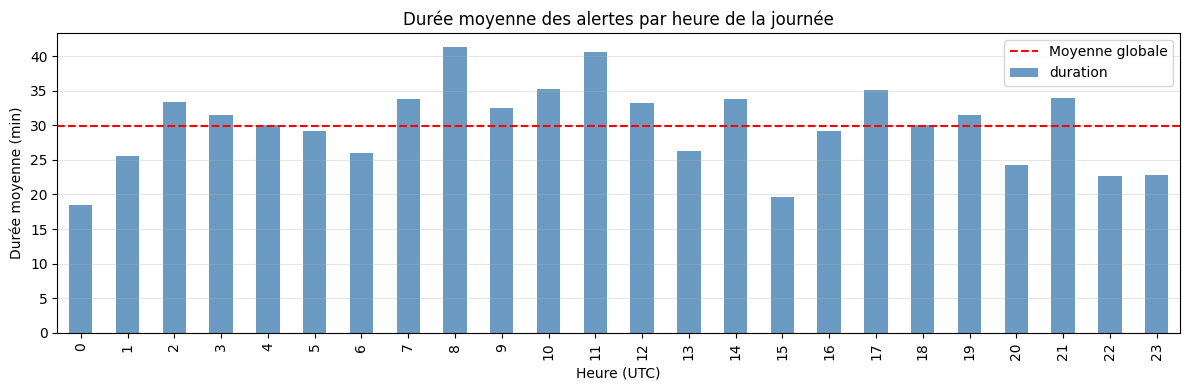

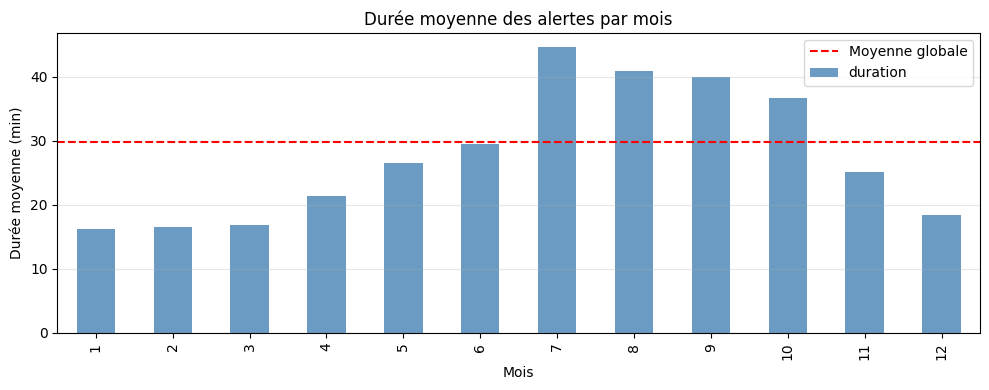

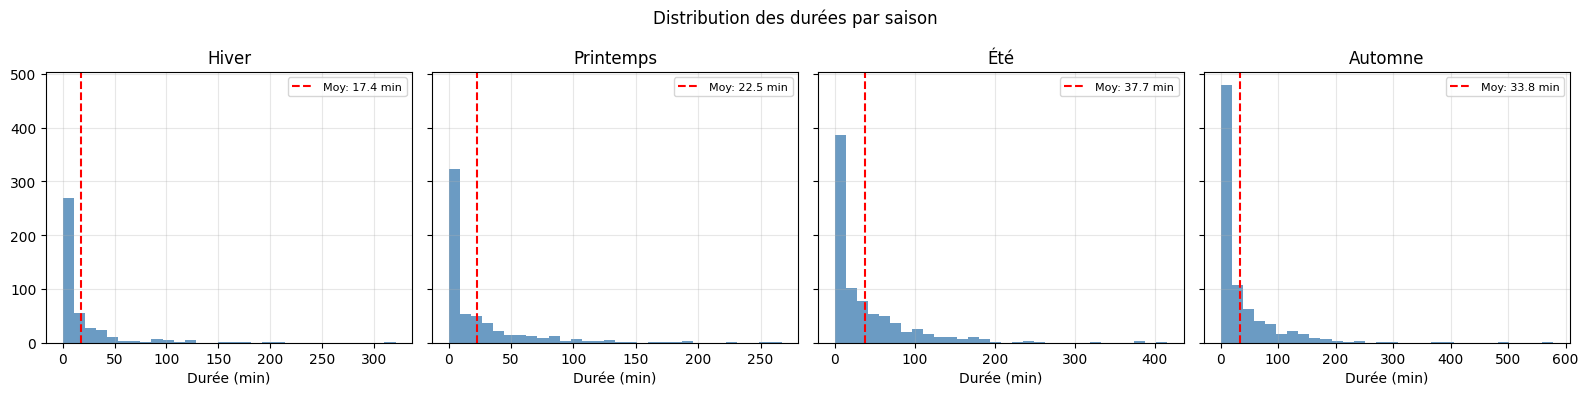

Durée moyenne par saison :
           mean  median  count
season                        
Automne    33.8    10.1    807
Hiver      17.4     2.6    419
Printemps  22.5     5.2    580
Été        37.7    16.8    821

Durée moyenne par heure (top 5 heures les plus longues) :
hour
8     41.3
11    40.6
10    35.2
17    35.0
21    33.9
Name: duration, dtype: float64

Correlation heure/durée : -0.004
Correlation mois/durée  : 0.066


In [9]:

# ── 1. Durée moyenne par heure ───────────────────────────────────────
plt.figure(figsize=(12, 4))
df.groupby("hour")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par heure de la journée")
plt.xlabel("Heure (UTC)")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 2. Durée moyenne par mois ────────────────────────────────────────
plt.figure(figsize=(10, 4))
df.groupby("month")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par mois")
plt.xlabel("Mois")
plt.ylabel("Durée moyenne (min)")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 3. Distribution des durées par saison ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, saison in zip(axes, ["Hiver", "Printemps", "Été", "Automne"]):
    data = df[df["season"] == saison]["duration"]
    ax.hist(data, bins=30, color="steelblue", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f} min")
    ax.set_title(saison)
    ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées par saison")
plt.tight_layout()
plt.show()

# ── 4. Stats résumées ────────────────────────────────────────────────
print("Durée moyenne par saison :")
print(df.groupby("season")["duration"].agg(["mean", "median", "count"]).round(1))

print("\nDurée moyenne par heure (top 5 heures les plus longues) :")
print(df.groupby("hour")["duration"].mean().sort_values(ascending=False).head(5).round(1))

print("\nCorrelation heure/durée :", df["hour"].corr(df["duration"]).round(3))
print("Correlation mois/durée  :", df["month"].corr(df["duration"]).round(3))